# Violence Detection CGN Model Builder

## Dependencies Import

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install optuna optuna-integration[tfkeras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 14.5 MB/s eta 0:00:00


In [28]:
import os
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [2]:
import tensorflow as tf

In [3]:
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, average_precision_score
from sklearn.preprocessing import label_binarize

In [ ]:
import optuna

## Config

In [30]:
tf.config.list_physical_devices('CPU')

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Device: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("Device: CPU")

Device: /physical_device:GPU:0


In [4]:
CLASSES = ['assault', 'fighting', 'shooting', 'robbery', 'normal_event']

ZIP_PATH = '/content/drive/MyDrive/Colab Notebooks/dataset/violence_dataset.zip'
EXTRACT_PATH = '/content/dataset'
SAVE_DIR = '/content/drive/MyDrive/GCN_Models_Output'

RANDOM_SEED = 67
BATCH_SIZE = 64

TRIAL_EPOCH = 20
TRIAL_N = 5

TRAIN_EPOCH = 120

In [ ]:
keras_model_path = os.path.join(SAVE_DIR, "GCN_LSTM_best.keras")
tflite_model_path = os.path.join(SAVE_DIR, "GCN_LSTM_best_int8.tflite")

In [6]:
if not os.path.exists(EXTRACT_PATH):
  print("Extracting Dataset...")
  with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
  print("Dataset has been extracted!")
else:
  print("Dataset has already been extracted previously")

Extracting Dataset...
Dataset has been extracted!


In [7]:
os.makedirs(SAVE_DIR, exist_ok=True)

## EDA

In [5]:
data_counts = {}
sample_shape = None

In [6]:
for cls in CLASSES:
  folder = os.path.join(EXTRACT_PATH, cls)
  if os.path.exists(folder):
    files = [f for f in os.listdir(folder) if f.endswith('.npy')]
    data_counts[cls] = len(files)

    if len(files) > 0 and sample_shape is None:
      sample_path = os.path.join(folder, files[0])
      sample_data = np.load(sample_path)
      sample_shape = sample_data.shape
  else:
    data_counts[cls] = 0

In [10]:
print(f".npy Dimension Sample (C, T, V, M): {sample_shape}")

.npy Dimension Sample (C, T, V, M): (3, 100, 17, 3)


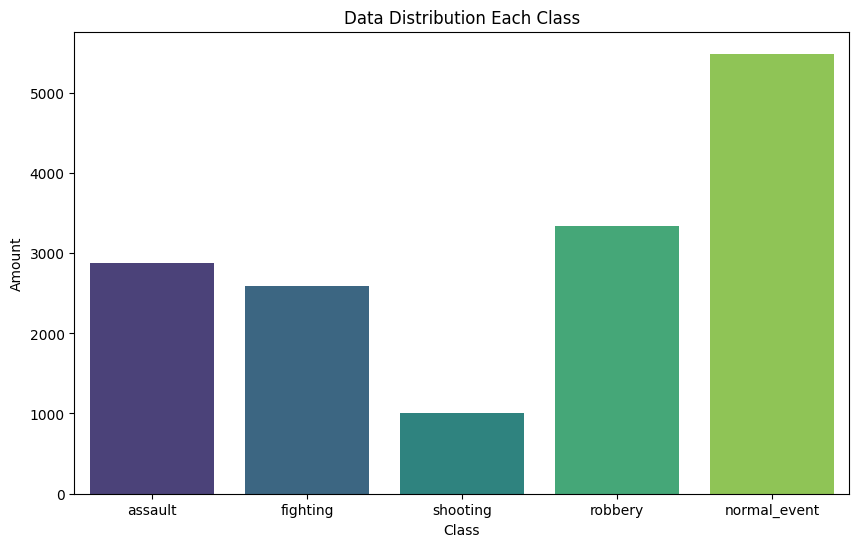

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(x=list(data_counts.keys()), y=list(data_counts.values()), hue=list(data_counts.keys()), palette="viridis", legend=False)
plt.title("Data Distribution Each Class")
plt.ylabel("Amount")
plt.xlabel("Class")
plt.show()

In [12]:
print("\nFile Amount Detail:")
for k, v in data_counts.items():
  print(f"- {k}: {v} files")


File Amount Detail:
- assault: 2871 files
- fighting: 2586 files
- shooting: 1002 files
- robbery: 3332 files
- normal_event: 5489 files


## Load Dataset

In [7]:
def create_dataset_generator(file_paths, labels):
    def generator():
        for path, label in zip(file_paths, labels):
            if isinstance(path, bytes):
                path = path.decode('utf-8')
            data = np.load(path).astype(np.float32)
            yield data, label
    return generator

In [8]:
all_files = []
all_labels = []

class_map = {cls_name: i for i, cls_name in enumerate(CLASSES)}

for cls in CLASSES:
  folder = os.path.join(EXTRACT_PATH, cls)
  if os.path.exists(folder):
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.npy')]
    all_files.extend(files)
    all_labels.extend([class_map[cls]] * len(files))

X_train, X_temp, y_train, y_temp = train_test_split(all_files, all_labels, test_size=0.30, random_state=RANDOM_SEED, stratify=all_labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1/3), random_state=RANDOM_SEED, stratify=y_temp)

In [15]:
print(f"Total Dataset: {len(all_files)}")
print(f"Train: {len(X_train)} (70%) | Val: {len(X_val)} (20%) | Test: {len(X_test)} (10%)")

Total Dataset: 15280
Train: 10696 (70%) | Val: 3056 (20%) | Test: 1528 (10%)


In [9]:
def build_tf_dataset(file_paths, labels, batch_size, shuffle=True):
    dataset = tf.data.Dataset.from_generator(
        create_dataset_generator(file_paths, labels),
        output_signature=(
            tf.TensorSpec(shape=(3, 100, 17, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int64)
        )
    )
    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(len(file_paths), 1000))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [10]:
train_dataset = build_tf_dataset(X_train, y_train, BATCH_SIZE, shuffle=True)
val_dataset = build_tf_dataset(X_val, y_val, BATCH_SIZE, shuffle=False)
test_dataset = build_tf_dataset(X_test, y_test, BATCH_SIZE, shuffle=False)

## Model Architecture

In [11]:
raw_edges = [
  (0, 1), (0, 2), (1, 3), (2, 4),
  (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
  (11, 12), (5, 11), (6, 12),
  (11, 13), (13, 15), (12, 14), (14, 16)
]

In [12]:
def get_adjacency_matrix():
  A = np.zeros((17, 17))
  for i, j in raw_edges:
    A[i, j] = 1
    A[j, i] = 1
  A = A + np.eye(17)

  # Normalize
  D = np.diag(np.sum(A, axis=1) ** (-0.5))
  A_norm = np.dot(np.dot(D, A), D)
  return tf.constant(A_norm, dtype=tf.float32)

A_tensor = get_adjacency_matrix()

In [13]:
# GCN Spatial Graph Block in Keras
@keras.utils.register_keras_serializable()
class GraphConv(layers.Layer):
    def __init__(self, out_channels, num_vertices=17, adaptive=True, **kwargs):
        super().__init__(**kwargs)
        self.out_channels = out_channels
        self.num_vertices = num_vertices
        self.adaptive = adaptive

    def build(self, input_shape):
        in_channels = input_shape[-1]

        self.conv = layers.Conv2D(self.out_channels, kernel_size=1, use_bias=False)
        self.bn = layers.BatchNormalization()

        if self.adaptive:
            # Menggunakan tf.Variable untuk parameter yang bisa dipelajari
            self.PA = self.add_weight(
                shape=(self.num_vertices, self.num_vertices),
                initializer=tf.keras.initializers.RandomNormal(stddev=1e-4),
                trainable=True,
                name='PA'
            )

        if in_channels != self.out_channels:
            self.down_sample = models.Sequential([
                layers.Conv2D(self.out_channels, kernel_size=1, use_bias=False),
                layers.BatchNormalization()
            ])
        else:
            self.down_sample = lambda x: x

        super().build(input_shape)

    def call(self, x, A=None):
        if A is None:
            A = get_adjacency_matrix()

        residual = self.down_sample(x)

        x = self.conv(x)

        if self.adaptive:
            A_dynamic = A + self.PA
            x_t = tf.transpose(x, [0, 1, 3, 2]) # (N, T, C, V)
            out = tf.matmul(x_t, A_dynamic) # (N, T, C, W)
            x = tf.transpose(out, [0, 1, 3, 2]) # (N, T, W, C)
        else:
            x_t = tf.transpose(x, [0, 1, 3, 2])
            out = tf.matmul(x_t, A)
            x = tf.transpose(out, [0, 1, 3, 2])

        x = self.bn(x)
        return tf.nn.relu(x + residual)

    def get_config(self):
        config = super().get_config()
        config.update({
            "out_channels": self.out_channels,
            "num_vertices": self.num_vertices,
            "adaptive": self.adaptive,
        })
        return config

In [14]:
# Temporal Attention Mechanism
@keras.utils.register_keras_serializable()
class TemporalAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        hidden_dim = input_shape[-1]
        self.dense1 = layers.Dense(hidden_dim // 2, activation='tanh')
        self.dense2 = layers.Dense(1)
        super().build(input_shape)

    def call(self, lstm_out):
        attn_scores = self.dense2(self.dense1(lstm_out))
        attn_weights = tf.nn.softmax(attn_scores, axis=1)
        context_vector = tf.reduce_sum(attn_weights * lstm_out, axis=1)
        return context_vector

    def get_config(self):
        config = super().get_config()
        return config

In [15]:
@keras.utils.register_keras_serializable()
class InputReshape(layers.Layer):
    def __init__(self, M=3, T=100, V=17, C=3, **kwargs):
        super().__init__(**kwargs)
        self.M = M
        self.T = T
        self.V = V
        self.C = C

    def call(self, inputs):
        x = tf.transpose(inputs, [0, 4, 2, 3, 1])
        x = tf.reshape(x, [-1, self.T, self.V, self.C])
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"M": self.M, "T": self.T, "V": self.V, "C": self.C})
        return config

@keras.utils.register_keras_serializable()
class SpatialPooling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, x):
        return tf.reduce_mean(x, axis=2)

@keras.utils.register_keras_serializable()
class LatePooling(layers.Layer):
    def __init__(self, M=3, hidden_dim=512, **kwargs):
        super().__init__(**kwargs)
        self.M = M
        self.hidden_dim = hidden_dim

    def call(self, x):
        x = tf.reshape(x, [-1, self.M, self.hidden_dim])
        return tf.reduce_max(x, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({"M": self.M, "hidden_dim": self.hidden_dim})
        return config

In [16]:
def build_gcn_lstm_model(num_classes=5, hidden_gcn=64, hidden_lstm=256, lstm_layers=2, dropout_rate=0.5, unroll=False):
    inputs = keras.Input(shape=(3, 100, 17, 3), name="input_tensor")

    M = 3
    T = 100
    V = 17
    C = 3

    x = InputReshape(M, T, V, C, name="early_reshape")(inputs)

    # --- SPATIAL GCN PROCESSING ---
    x = GraphConv(hidden_gcn, V, adaptive=True)(x, A_tensor)
    x = GraphConv(hidden_gcn * 2, V, adaptive=True)(x, A_tensor)
    x = GraphConv(hidden_gcn * 4, V, adaptive=True)(x, A_tensor)

    x = SpatialPooling(name="spatial_pooling")(x)

    # --- TEMPORAL CONVOLUTION (TCN) ---
    x = layers.Conv1D(hidden_gcn * 4, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # --- LSTM PROCESSING ---
    for i in range(lstm_layers):
        lstm_layer = layers.LSTM(hidden_lstm, return_sequences=True, dropout=dropout_rate if lstm_layers > 1 else 0.0, unroll=unroll)
        x = layers.Bidirectional(lstm_layer)(x)

    # --- TEMPORAL ATTENTION ---
    x = TemporalAttention()(x)

    # --- LATE POOLING (MENGAMBIL INTERAKSI M ORANG) ---
    x = LatePooling(M=M, hidden_dim=hidden_lstm * 2, name="late_pooling")(x)

    # --- KLASIFIKASI AKHIR ---
    x = layers.Dense(hidden_lstm, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="GCN_LSTM")
    return model

## Hyper Parameter Tuning

In [24]:
def objective(trial):
    print(f"\n--- Starting Trial {trial.number} ---")
    keras.backend.clear_session()

    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    hidden_gcn = trial.suggest_categorical("hidden_gcn", [32, 64, 128])
    hidden_lstm = trial.suggest_categorical("hidden_lstm", [128, 256, 512])
    lstm_layers = trial.suggest_int("lstm_layers", 1, 3)
    dropout_rate = trial.suggest_float("dropout", 0.3, 0.6)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

    model = build_gcn_lstm_model(
        num_classes=len(CLASSES),
        hidden_gcn=hidden_gcn,
        hidden_lstm=hidden_lstm,
        lstm_layers=lstm_layers,
        dropout_rate=dropout_rate
    )

    optimizer = optimizers.Adam(learning_rate=lr, weight_decay=weight_decay)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=TRIAL_EPOCH,
        callbacks=[early_stop, optuna.integration.TFKerasPruningCallback(trial, "val_loss")],
        verbose=2
    )

    return min(history.history['val_loss'])

In [25]:
study_gcn_lstm = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())

[I 2026-05-14 15:17:03,210] A new study created in memory with name: no-name-135f3351-8e19-46f9-9c9e-5ea0d098ff40


In [26]:
study_gcn_lstm.optimize(objective, n_trials=TRIAL_N)


--- Starting Trial 0 ---
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


168/168 - 45s - 270ms/step - accuracy: 0.3752 - loss: 1.4654 - val_accuracy: 0.4195 - val_loss: 1.4237
Epoch 2/20
168/168 - 31s - 186ms/step - accuracy: 0.4427 - loss: 1.3430 - val_accuracy: 0.4866 - val_loss: 1.2445
Epoch 3/20
168/168 - 31s - 187ms/step - accuracy: 0.4799 - loss: 1.2631 - val_accuracy: 0.5164 - val_loss: 1.1796
Epoch 4/20
168/168 - 32s - 188ms/step - accuracy: 0.5066 - loss: 1.2074 - val_accuracy: 0.5236 - val_loss: 1.1559
Epoch 5/20
168/168 - 32s - 188ms/step - accuracy: 0.5251 - loss: 1.1718 - val_accuracy: 0.5478 - val_loss: 1.1444
Epoch 6/20
168/168 - 31s - 187ms/step - accuracy: 0.5403 - loss: 1.1425 - val_accuracy: 0.5416 - val_loss: 1.1282
Epoch 7/20
168/168 - 32s - 188ms/step - accuracy: 0.5496 - loss: 1.1151 - val_accuracy: 0.5782 - val_loss: 1.0627
Epoch 8/20
168/168 - 32s - 188ms/step - accuracy: 0.5613 - loss: 1.0913 - val_accuracy: 0.5906 - val_loss: 1.0287
Epoch 9/20
168/168 - 32s - 188ms/step - accuracy: 0.5757 - loss: 1.0626 - val_accuracy: 0.5782 - va

[I 2026-05-14 15:27:50,198] Trial 0 finished with value: 0.8316282033920288 and parameters: {'lr': 0.00025177374586406306, 'hidden_gcn': 32, 'hidden_lstm': 128, 'lstm_layers': 2, 'dropout': 0.5103190244669159, 'weight_decay': 0.0006062875239489254}. Best is trial 0 with value: 0.8316282033920288.



--- Starting Trial 1 ---
Epoch 1/20
168/168 - 78s - 463ms/step - accuracy: 0.3920 - loss: 1.4396 - val_accuracy: 0.3835 - val_loss: 1.4366
Epoch 2/20
168/168 - 66s - 390ms/step - accuracy: 0.4271 - loss: 1.3747 - val_accuracy: 0.4156 - val_loss: 1.4188
Epoch 3/20
168/168 - 66s - 390ms/step - accuracy: 0.4381 - loss: 1.3655 - val_accuracy: 0.4143 - val_loss: 1.4234
Epoch 4/20
168/168 - 66s - 390ms/step - accuracy: 0.4571 - loss: 1.3197 - val_accuracy: 0.4601 - val_loss: 1.3077
Epoch 5/20
168/168 - 66s - 391ms/step - accuracy: 0.4558 - loss: 1.3322 - val_accuracy: 0.4594 - val_loss: 1.2988
Epoch 6/20
168/168 - 66s - 390ms/step - accuracy: 0.4760 - loss: 1.2887 - val_accuracy: 0.4791 - val_loss: 1.3050
Epoch 7/20
168/168 - 66s - 390ms/step - accuracy: 0.4830 - loss: 1.2667 - val_accuracy: 0.4980 - val_loss: 1.2116
Epoch 8/20
168/168 - 66s - 390ms/step - accuracy: 0.4931 - loss: 1.2453 - val_accuracy: 0.5036 - val_loss: 1.2035
Epoch 9/20
168/168 - 66s - 390ms/step - accuracy: 0.4993 - los

...

[I 2026-05-14 16:32:02,570] Trial 2 finished with value: 0.7064666152000427 and parameters: {'lr': 0.00023012038706597335, 'hidden_gcn': 128, 'hidden_lstm': 512, 'lstm_layers': 2, 'dropout': 0.5840699218508336, 'weight_decay': 0.0006328530094304036}. Best is trial 2 with value: 0.7064666152000427.



--- Starting Trial 3 ---
Epoch 1/20
168/168 - 71s - 420ms/step - accuracy: 0.3780 - loss: 1.4660 - val_accuracy: 0.3802 - val_loss: 1.4987
Epoch 2/20
168/168 - 61s - 363ms/step - accuracy: 0.4289 - loss: 1.3642 - val_accuracy: 0.4607 - val_loss: 1.3777
Epoch 3/20
168/168 - 61s - 363ms/step - accuracy: 0.4684 - loss: 1.2931 - val_accuracy: 0.5033 - val_loss: 1.2968
Epoch 4/20
168/168 - 61s - 363ms/step - accuracy: 0.4979 - loss: 1.2285 - val_accuracy: 0.5121 - val_loss: 1.2072
Epoch 5/20
168/168 - 61s - 362ms/step - accuracy: 0.5251 - loss: 1.1855 - val_accuracy: 0.5049 - val_loss: 1.2129
Epoch 6/20
168/168 - 61s - 363ms/step - accuracy: 0.5258 - loss: 1.1604 - val_accuracy: 0.5471 - val_loss: 1.1770
Epoch 7/20
168/168 - 61s - 363ms/step - accuracy: 0.5475 - loss: 1.1309 - val_accuracy: 0.5789 - val_loss: 1.1027
Epoch 8/20
168/168 - 61s - 363ms/step - accuracy: 0.5624 - loss: 1.0989 - val_accuracy: 0.5484 - val_loss: 1.1611
Epoch 9/20
168/168 - 61s - 363ms/step - accuracy: 0.5788 - los

[I 2026-05-14 16:52:32,018] Trial 3 finished with value: 0.8338117599487305 and parameters: {'lr': 0.00019389758140577748, 'hidden_gcn': 64, 'hidden_lstm': 256, 'lstm_layers': 2, 'dropout': 0.5957302034144838, 'weight_decay': 8.30606293240005e-05}. Best is trial 2 with value: 0.7064666152000427.



--- Starting Trial 4 ---
Epoch 1/20
168/168 - 51s - 305ms/step - accuracy: 0.3930 - loss: 1.4398 - val_accuracy: 0.4306 - val_loss: 1.4797
Epoch 2/20
168/168 - 40s - 237ms/step - accuracy: 0.4165 - loss: 1.3976 - val_accuracy: 0.4224 - val_loss: 1.3991
Epoch 3/20
168/168 - 40s - 236ms/step - accuracy: 0.4265 - loss: 1.3825 - val_accuracy: 0.4490 - val_loss: 1.3161
Epoch 4/20
168/168 - 40s - 237ms/step - accuracy: 0.4441 - loss: 1.3418 - val_accuracy: 0.3927 - val_loss: 1.3986
Epoch 5/20
168/168 - 40s - 236ms/step - accuracy: 0.4341 - loss: 1.3343 - val_accuracy: 0.4607 - val_loss: 1.3033
Epoch 6/20
168/168 - 40s - 237ms/step - accuracy: 0.4668 - loss: 1.2903 - val_accuracy: 0.4813 - val_loss: 1.2408
Epoch 7/20
168/168 - 40s - 237ms/step - accuracy: 0.4725 - loss: 1.2708 - val_accuracy: 0.4840 - val_loss: 1.2140
Epoch 8/20
168/168 - 40s - 236ms/step - accuracy: 0.4776 - loss: 1.2423 - val_accuracy: 0.4827 - val_loss: 1.2417
Epoch 9/20
168/168 - 40s - 236ms/step - accuracy: 0.4766 - los

[I 2026-05-14 17:05:59,061] Trial 4 finished with value: 1.1134908199310303 and parameters: {'lr': 0.0018050162616296396, 'hidden_gcn': 32, 'hidden_lstm': 256, 'lstm_layers': 3, 'dropout': 0.48433462090245494, 'weight_decay': 0.00014991265719164573}. Best is trial 2 with value: 0.7064666152000427.


In [27]:
print("=== Best Params ===")
print(study_gcn_lstm.best_params)

=== Best Params ===
{'lr': 0.00023012038706597335, 'hidden_gcn': 128, 'hidden_lstm': 512, 'lstm_layers': 2, 'dropout': 0.5840699218508336, 'weight_decay': 0.0006328530094304036}


## Model Training

In [17]:
# best_params = study_gcn_lstm.best_params
best_params = {'lr': 0.00023012038706597335, 'hidden_gcn': 128, 'hidden_lstm': 512, 'lstm_layers': 2, 'dropout': 0.5840699218508336, 'weight_decay': 0.0006328530094304036}

In [19]:
keras.backend.clear_session()

In [31]:
model = build_gcn_lstm_model(
    num_classes=len(CLASSES),
    hidden_gcn=best_params['hidden_gcn'],
    hidden_lstm=best_params['hidden_lstm'],
    lstm_layers=best_params['lstm_layers'],
    dropout_rate=best_params['dropout']
)

optimizer = optimizers.Adam(learning_rate=best_params['lr'], weight_decay=best_params['weight_decay'])
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [32]:
model.summary()

Model: "GCN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tensor (InputLayer)       │ (None, 3, 100, 17, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ early_reshape (InputReshape)    │ (None, 100, 17, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv (GraphConv)          │ (None, 100, 17, 128)   │         2,081 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_1 (GraphConv)        │ (None, 100, 17, 256)   │        67,873 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_2 (GraphConv)        │ (None, 100, 17, 512)   │       266,529 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_pooling                 │ (None, 100, 512)       │             0 │
│ (SpatialPooling)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 512)       │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 100, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 1024)      │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 100, 1024)      │     6,295,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ (None, 1024)           │       525,313 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ late_pooling (LatePooling)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,672,105 (48.34 MB)

 Trainable params: 12,667,497 (48.32 MB)

 Non-trainable params: 4,608 (18.00 KB)

In [33]:
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20, min_lr=1e-6)
model_checkpoint = callbacks.ModelCheckpoint(keras_model_path, monitor='val_loss', save_best_only=True, verbose=1)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)

In [34]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=TRAIN_EPOCH,
    callbacks=[reduce_lr, model_checkpoint, early_stopping]
)

Epoch 1/120
    168/Unknown 128s 708ms/step - accuracy: 0.3666 - loss: 1.4903
Epoch 1: val_loss improved from None to 1.47178, saving model to /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 139s 772ms/step - accuracy: 0.3890 - loss: 1.4417 - val_accuracy: 0.4025 - val_loss: 1.4718 - learning_rate: 2.3012e-04
Epoch 2/120
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.4605 - loss: 1.3144
Epoch 2: val_loss improved from 1.47178 to 1.30937, saving model to /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 127s 751ms/step - accuracy: 0.4717 - loss: 1.2914 - val_accuracy: 0.4653 - val_loss: 1.3094 - learning_rate: 2.3012e-04
Epoch 3/120
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.5071 - loss: 1.2121

## Train Result

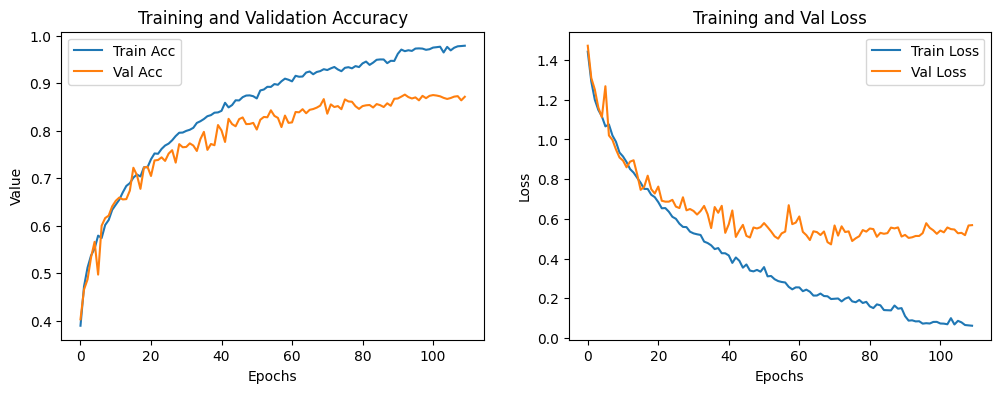

In [35]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Model Test

In [37]:
model = keras.models.load_model(keras_model_path, custom_objects={
    'GraphConv': GraphConv,
    'TemporalAttention': TemporalAttention,
    'InputReshape': InputReshape,
    'SpatialPooling': SpatialPooling,
    'LatePooling': LatePooling
})

test_loss, test_acc = model.evaluate(test_dataset)

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.8455 - loss: 0.5539


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [38]:
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc: {test_acc:.4f}")

Test Loss: 0.5539
Test Acc: 0.8455


In [40]:
y_pred_prob = model.predict(test_dataset)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_true_bin = label_binarize(y_true, classes=range(len(CLASSES)))

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [41]:
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))


=== Classification Report ===
              precision    recall  f1-score   support

     assault     0.8044    0.7596    0.7814       287
    fighting     0.7621    0.8533    0.8051       259
    shooting     0.8316    0.7900    0.8103       100
     robbery     0.8149    0.8198    0.8174       333
normal_event     0.9330    0.9126    0.9227       549

    accuracy                         0.8455      1528
   macro avg     0.8292    0.8271    0.8273      1528
weighted avg     0.8475    0.8455    0.8459      1528



In [42]:
print("=== Average Precision (AP) per class ===")
ap_scores = []
for i, cls in enumerate(CLASSES):
    ap = average_precision_score(y_true_bin[:, i], y_pred_prob[:, i])
    ap_scores.append(ap)
    print(f"{cls}: {ap:.4f}")

mAP = np.mean(ap_scores)
print(f"\nMean Average Precision (mAP50 equivalent): {mAP:.4f}")

=== Average Precision (AP) per class ===
assault: 0.8810
fighting: 0.8968
shooting: 0.8538
robbery: 0.9032
normal_event: 0.9795

Mean Average Precision (mAP50 equivalent): 0.9029


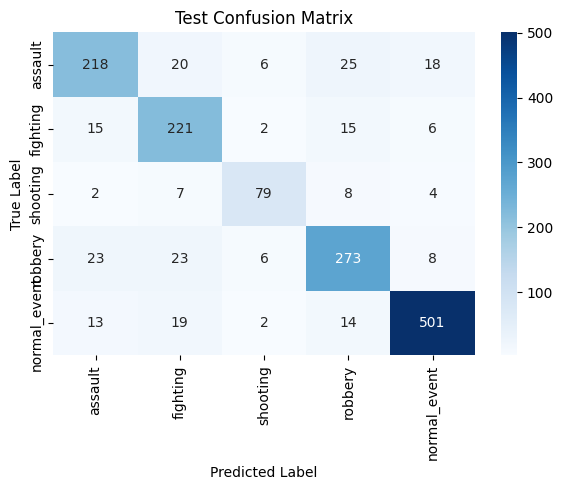

In [43]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## TFLite Conversion (Full Integer Quantization)

In [20]:
def build_tflite_model(best_params, num_classes=5):
    inputs = keras.Input(batch_shape=(1, 3, 100, 17, 3), name="input_tensor")

    M = 3; T = 100; V = 17; C = 3
    x = InputReshape(M, T, V, C, name="early_reshape")(inputs)

    x = GraphConv(best_params['hidden_gcn'], V, adaptive=True)(x, A_tensor)
    x = GraphConv(best_params['hidden_gcn'] * 2, V, adaptive=True)(x, A_tensor)
    x = GraphConv(best_params['hidden_gcn'] * 4, V, adaptive=True)(x, A_tensor)
    x = SpatialPooling(name="spatial_pooling")(x)

    x = layers.Conv1D(best_params['hidden_gcn'] * 4, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    for i in range(best_params['lstm_layers']):
        lstm_layer = layers.LSTM(best_params['hidden_lstm'], return_sequences=True, unroll=True)
        x = layers.Bidirectional(lstm_layer)(x)

    x = TemporalAttention()(x)
    x = LatePooling(M=M, hidden_dim=best_params['hidden_lstm'] * 2, name="late_pooling")(x)

    x = layers.Dense(best_params['hidden_lstm'], activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs=inputs, outputs=outputs)

In [21]:
def representative_data_gen():
    for input_value, _ in train_dataset.unbatch().batch(1).take(100):
        yield [input_value]

In [22]:
with tf.device('/CPU:0'):
    saved_model = keras.models.load_model(keras_model_path, custom_objects={
        'GraphConv': GraphConv,
        'TemporalAttention': TemporalAttention,
        'InputReshape': InputReshape,
        'SpatialPooling': SpatialPooling,
        'LatePooling': LatePooling
    })

    model_for_tflite = build_tflite_model(best_params, len(CLASSES))
    model_for_tflite.set_weights(saved_model.get_weights())

In [23]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_for_tflite)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

In [24]:
print("Konversi model ke TFLite...")
try:
    tflite_quant_model = converter.convert()
    with open(tflite_model_path, 'wb') as f:
        f.write(tflite_quant_model)
    print(f"TFLite model successfully saved to {tflite_model_path}")

    model_size_kb = os.path.getsize(tflite_model_path) / 1024
    print(f"Quantized Model Size: {model_size_kb:.2f} KB")
except Exception as e:
    print(f"Failed to convert model to TFLite: {e}")

Konversi model ke TFLite...
Saved artifact at '/tmp/tmpxqp727ok'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 3, 100, 17, 3), dtype=tf.float32, name='input_tensor')
Output Type:
  TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)
Captures:
  134028975413712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134028849661520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134028849661328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134028849660944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134028849662096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134028849660176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134028975416208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134028977953232: TensorSpec(shape=(17, 17), dtype=tf.float32, name=None)
  134028849661712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134028849661904: TensorSpec(shape=(), dtype=tf.resource

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite model successfully saved to /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best_int8.tflite
Quantized Model Size: 15611.88 KB


## Compile with Edge TPU Compiler

reference: [coral.ai Web-based Edge TPU Compiler](https://colab.research.google.com/github/google-coral/tutorials/blob/master/compile_for_edgetpu.ipynb)

In [26]:
! curl https://packages.cloud.google.com/apt/doc/apt-key.gpg | sudo apt-key add -

! echo "deb https://packages.cloud.google.com/apt coral-edgetpu-stable main" | sudo tee /etc/apt/sources.list.d/coral-edgetpu.list

! sudo apt-get update

! sudo apt-get install edgetpu-compiler

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1022  100  1022    0     0  13754      0 --:--:-- --:--:-- --:--:-- 13810
OK
deb https://packages.cloud.google.com/apt coral-edgetpu-stable main
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://packages.cloud.google.com/apt coral-edgetpu-stable InRelease [1,423 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,644 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 https://packages.cloud.google.com/apt coral-edgetpu-stable/main all Packages [1,865 B]
Get:9 http://security.ubuntu.co

In [27]:
!edgetpu_compiler {tflite_model_path}

Edge TPU Compiler version 16.0.384591198
Started a compilation timeout timer of 180 seconds.

Model compiled successfully in 69782 ms.

Input model: /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best_int8.tflite
Input size: 15.25MiB
Output model: GCN_LSTM_best_int8_edgetpu.tflite
Output size: 28.26MiB
On-chip memory used for caching model parameters: 6.11MiB
On-chip memory remaining for caching model parameters: 1.80MiB
Off-chip memory used for streaming uncached model parameters: 6.19MiB
Number of Edge TPU subgraphs: 1
Total number of operations: 5635
Operation log: GCN_LSTM_best_int8_edgetpu.log

Model successfully compiled but not all operations are supported by the Edge TPU. A percentage of the model will instead run on the CPU, which is slower. If possible, consider updating your model to use only operations supported by the Edge TPU. For details, visit g.co/coral/model-reqs.
Number of operations that will run on Edge TPU: 2790
Number of operations that will run on CPU: 2845
S

In [29]:
base_path, ext = os.path.splitext(tflite_model_path)
edgetpu_dest_path = f"{base_path}_edgetpu{ext}"

edgetpu_source_filename = f"{os.path.basename(base_path)}_edgetpu{ext}"
edgetpu_source_path = os.path.join('/content', edgetpu_source_filename)

# Memindahkan file jika ada
if os.path.exists(edgetpu_source_path):
    shutil.move(edgetpu_source_path, edgetpu_dest_path)
    print(f"Model Edge TPU berhasil dipindahkan ke: {edgetpu_dest_path}")
else:
    print(f"Gagal memindahkan. File sumber tidak ditemukan: {edgetpu_source_path}")

Model Edge TPU berhasil dipindahkan ke: /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best_int8_edgetpu.tflite


## Additionaly convert YOLO Model to Edge TPU TFLite as well

In [33]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.1 MB/s eta 0:00:00


In [34]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [35]:
model = YOLO('yolov8n-pose.pt')

In [36]:
model.export(format='edgetpu', imgsz=320, int8=True)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
WARNING ⚠️ EDGETPU export does not support end2end models, disabling end2end branch.
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8-pose.yaml'.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n-pose summary (fused): 81 layers, 3,289,964 parameters, 0 gradients, 9.2 GFLOPs

PyTorch: starting from 'yolov8n-pose.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 56, 2100) (6.5 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=coco8-pose.yaml'

WARNING ⚠️ Dataset 'coco8-pose.yaml' images not found, missing path '/content/datasets/coco8-pose/images/val'
Unzipping /content/datasets/coco8-pose.zip to /content/datasets/coco8-pose...: 100% ━━━━━━━━━━━━ 27/27 4.1Kfiles/s 0.0s
Dataset download success ✅ (0.6s), saved to /conten

'yolov8n-pose_saved_model/yolov8n-pose_full_integer_quant_edgetpu.tflite'

In [39]:
edgetpu_yolo_model_path = "/content/yolov8n-pose_saved_model/yolov8n-pose_full_integer_quant_edgetpu.tflite"

In [40]:
yolo_base_path, yolo_ext = os.path.splitext(edgetpu_yolo_model_path)

yolo_edgetpu_source_filename = f"{os.path.basename(yolo_base_path)}{yolo_ext}"
yolo_edgetpu_dest_path = os.path.join(SAVE_DIR, yolo_edgetpu_source_filename)

# Memindahkan file jika ada
if os.path.exists(edgetpu_yolo_model_path):
    shutil.move(edgetpu_yolo_model_path , yolo_edgetpu_dest_path)
    print(f"Model Edge TPU berhasil dipindahkan ke: {yolo_edgetpu_dest_path}")
else:
    print(f"Gagal memindahkan. File sumber tidak ditemukan: {edgetpu_yolo_model_path}")

Model Edge TPU berhasil dipindahkan ke: /content/drive/MyDrive/GCN_Models_Output/yolov8n-pose_full_integer_quant_edgetpu.tflite
